### Tailing the Hedge

simular 30 días de mercado para una empresa que quiere cubrir una posición de 100,000 barriles de petróleo usando contratos de futuros (cada contrato es de 1,000 barriles).
- Cobertura Convencional (Estática): Calcula el número de contratos fijos de forma lineal desde el día uno.
- Cobertura con Tailing (Dinámica): Ajusta el número de contratos día con día usando el valor presente de la posición y la volatilidad de los rendimientos diarios.

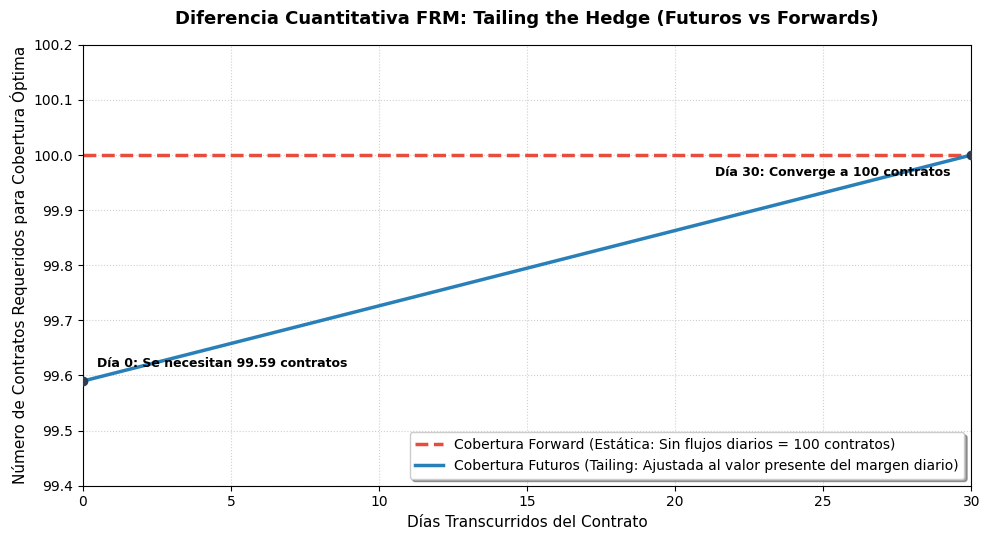

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


Q_spot = 100000        # Cantidad total de barriles a cubrir
Q_future = 1000        # Tamaño de cada contrato de futuros (1,000 barriles)
dias_totales = 30      # Plazo de la cobertura en días
tasa_anual = 0.05      # Tasa libre de riesgo (5% anual para el valor del dinero en el tiempo)

# Crear vector de días transcurridos de 0 a 30
dias_transcurridos = np.arange(dias_totales + 1)

# Tiempo restante (tau) expresado en años para cada día del contrato
tau = (dias_totales - dias_transcurridos) / 365.0

# --- 2. CÁLCULO DE LAS DOS COBERTURAS ---
# Cobertura Estática (Forwards): No se ajusta porque no hay flujos diarios. Siempre son 100 contratos.
contratos_forward = np.full(len(dias_transcurridos), Q_spot / Q_future)

# Cobertura Dinámica (Futuros - Tailing the Hedge): Se multiplica por e^(-r * tau)
# Al usar rendimientos porcentuales diarios, el analista descuenta los flujos que faltan por liquidar.
contratos_futuros = (Q_spot / Q_future) * np.exp(-tasa_anual * tau)

# --- 3. DISEÑO DE LA GRÁFICA COMPARATIVA ---
plt.figure(figsize=(10, 5.5))

# Línea para el Forward (Línea recta constante)
plt.plot(dias_transcurridos, contratos_forward, 
         label='Cobertura Forward (Estática: Sin flujos diarios = 100 contratos)', 
         color='#e74c3c', linestyle='--', linewidth=2.5)

# Línea para el Futuro (Curva ascendente)
plt.plot(dias_transcurridos, contratos_futuros, 
         label='Cobertura Futuros (Tailing: Ajustada al valor presente del margen diario)', 
         color='#2980b9', linewidth=2.5)

# Detalles y anotaciones de la gráfica para el análisis cuantitativo
plt.title('Diferencia Cuantitativa FRM: Tailing the Hedge (Futuros vs Forwards)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Días Transcurridos del Contrato', fontsize=11)
plt.ylabel('Número de Contratos Requeridos para Cobertura Óptima', fontsize=11)
plt.xlim(0, dias_totales)
plt.ylim(99.4, 100.2) # Ajuste de zoom para ver el sutil pero crítico impacto matemático
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

# Anotaciones de los puntos clave detectados en la simulación
plt.scatter([0, 30], [contratos_futuros[0], contratos_futuros[-1]], color='#2c3e50', zorder=5)
plt.annotate(f'Día 0: Se necesitan {contratos_futuros[0]:.2f} contratos', (0, contratos_futuros[0]), 
             textcoords="offset points", xytext=(10,10), ha='left', fontsize=9, fontweight='bold')
plt.annotate(f'Día 30: Converge a {contratos_futuros[-1]:.0f} contratos', (30, contratos_futuros[-1]), 
             textcoords="offset points", xytext=(-15,-15), ha='right', fontsize=9, fontweight='bold')

# Desplegar el resultado visual
plt.tight_layout()
plt.show()
